In [1]:
from torchvision.transforms import Compose
from torchvision.transforms import Lambda
from torchvision.transforms import Normalize
from torchvision.transforms import Resize
from torchvision.transforms import ToTensor

import sys
import torch
from PIL import Image
from pathlib import Path

from torch.nn import Sequential, Conv2d, ReLU, Module, MaxPool2d, Linear, Flatten
from torch.nn import BatchNorm2d, Dropout2d, Dropout
from src.data.dataset import create_data_loaders

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# This code defines the main project directory and the paths to the source code and saved model files.
PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

X_MODEL_PATH = PROJECT_ROOT / "04_models" / "base_cnn.pth"
Y_MODEL_PATH = PROJECT_ROOT / "04_models" / "model_BatchNormAndDropoutCNN.pth"

print(Y_MODEL_PATH)

C:\Users\sveto\OneDrive\Desktop\cats_and_dogs_classification\04_models\model_BatchNormAndDropoutCNN.pth


In [3]:
# This path points to the `random_imgs` directory located in the current working directory.
# The folder contains random images that are used to evaluate the trained model on unseen samples outside the test dataset.
RANDOM_IMAGES_DIR = Path.cwd() / "random_imgs"

### Base experiment

In [4]:
# This class defines a basic Convolutional Neural Network for binary image classification.
# The model is divided into two main parts:
# features extracts visual patterns from the input images.
# classifier uses the extracted features to predict one of two classes.

class BaseCNN(Module):

    def __init__(self):
        super().__init__()

        self.features = Sequential(
            Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            ReLU(),
            MaxPool2d(kernel_size=2),

            Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            ReLU(),
            MaxPool2d(kernel_size=2),
        )

        self.classifier = Sequential(
            Flatten(),
            Linear(in_features=64 * 32 * 32, out_features=128),
            ReLU(),
            Linear(in_features=128, out_features=2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [5]:
# Load the Trained Base CNN Model
# This code creates an instance of the `BaseCNN` architecture and loads the previously saved model parameters from `X_MODEL_PATH`.
model = BaseCNN()

model.load_state_dict(
    torch.load(
        X_MODEL_PATH,
        map_location="cpu",
        weights_only=True,
    )
)

model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [6]:
#This function creates and returns the data loaders for the three dataset
train_loader, validation_loader, test_loader = create_data_loaders()

In [7]:
# Evaluate the Model on the Test Dataset
# This code calculates the model classification accuracy on the unseen test dataset.
correct_predictions = 0
total_samples = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

test_accuracy = correct_predictions / total_samples

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test accuracy: 0.7929
Test accuracy: 79.29%


In [8]:
# This transformation pipeline prepares external images before they are passed to the trained model
prediction_transform = Compose([
    Resize((128, 128)),
    ToTensor(),
    Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

In [9]:
# This function loads one image, applies the required transformations, and uses the trained model to predict its class.
def predict_image(model, image_path, transform, class_names):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)

        predicted_index = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_index].item()

    predicted_class = class_names[predicted_index]

    return predicted_class, confidence

In [10]:
model = BaseCNN()

model.load_state_dict(
    torch.load(
        X_MODEL_PATH,
        map_location="cpu",
        weights_only=True,
    )
)

model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [11]:
class_names = test_loader.dataset.classes

supported_extensions = {".jpg", ".jpeg", ".png"}

for image_path in sorted(RANDOM_IMAGES_DIR.iterdir()):

    if image_path.suffix.lower() not in supported_extensions:
        continue

    predicted_class, confidence = predict_image(
        model=model,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )

    print(
        f"{image_path.name}: "
        f"prediction={predicted_class}, "
        f"confidence={confidence:.2%}"
    )

764036571_2853828071657706_3269612040631983897_n.jpg: prediction=dogs, confidence=53.81%
c1.jpg: prediction=cats, confidence=59.06%
c11.jpg: prediction=cats, confidence=68.29%
c111.jpg: prediction=cats, confidence=57.07%
c2.jpg: prediction=cats, confidence=83.53%
c22.jpg: prediction=cats, confidence=57.27%
c3.jpg: prediction=dogs, confidence=97.33%
c33.jpg: prediction=cats, confidence=60.97%
c4.jpg: prediction=cats, confidence=94.91%
c44.jpg: prediction=dogs, confidence=78.97%
c5.jpg: prediction=dogs, confidence=97.38%
c55.jpg: prediction=dogs, confidence=91.17%
cat-1.jpg: prediction=cats, confidence=59.06%
cat-10.jpg: prediction=dogs, confidence=52.19%
cat-11.jpg: prediction=dogs, confidence=52.60%
cat-12.jpg: prediction=dogs, confidence=71.99%
cat-13.jpg: prediction=dogs, confidence=79.06%
cat-14.jpg: prediction=cats, confidence=67.20%
cat-15.jpg: prediction=dogs, confidence=70.01%
cat-16.jpg: prediction=cats, confidence=88.90%
cat-17.jpg: prediction=cats, confidence=92.87%
cat-18.jp

X:\venvs\main_int\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [12]:
correct_predictions = 0
total_images = 0

for image_path in sorted(RANDOM_IMAGES_DIR.iterdir()):

    if image_path.suffix.lower() not in supported_extensions:
        continue

    predicted_class, confidence = predict_image(
        model=model,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )

    if image_path.stem.startswith("cat"):
        actual_class = "cats"
    elif image_path.stem.startswith("dog"):
        actual_class = "dogs"
    else:
        continue

    is_correct = predicted_class == actual_class

    correct_predictions += int(is_correct)
    total_images += 1

    print(
        f"{image_path.name} | "
        f"Actual: {actual_class} | "
        f"Predicted: {predicted_class} | "
        f"Confidence: {confidence:.2%} | "
        f"Correct: {is_correct}"
    )

external_accuracy = correct_predictions / total_images

print()
print(f"Correct predictions: {correct_predictions}/{total_images}")
print(f"External images accuracy: {external_accuracy:.2%}")

cat-1.jpg | Actual: cats | Predicted: cats | Confidence: 59.06% | Correct: True
cat-10.jpg | Actual: cats | Predicted: dogs | Confidence: 52.19% | Correct: False
cat-11.jpg | Actual: cats | Predicted: dogs | Confidence: 52.60% | Correct: False
cat-12.jpg | Actual: cats | Predicted: dogs | Confidence: 71.99% | Correct: False
cat-13.jpg | Actual: cats | Predicted: dogs | Confidence: 79.06% | Correct: False
cat-14.jpg | Actual: cats | Predicted: cats | Confidence: 67.20% | Correct: True
cat-15.jpg | Actual: cats | Predicted: dogs | Confidence: 70.01% | Correct: False
cat-16.jpg | Actual: cats | Predicted: cats | Confidence: 88.90% | Correct: True
cat-17.jpg | Actual: cats | Predicted: cats | Confidence: 92.87% | Correct: True
cat-18.jpg | Actual: cats | Predicted: cats | Confidence: 89.54% | Correct: True
cat-19.jpg | Actual: cats | Predicted: cats | Confidence: 89.40% | Correct: True
cat-2.jpg | Actual: cats | Predicted: dogs | Confidence: 64.83% | Correct: False
cat-20.jpg | Actual: cat

### Experiment 2: CNN with Batch Normalization and Dropout
---

In [13]:
class BatchNormAndDropoutCNN(Module):

    def __init__(self):
        super().__init__()

        self.features = Sequential(
            Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            BatchNorm2d(num_features=32),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            BatchNorm2d(num_features=64),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            BatchNorm2d(num_features=128),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.3),

            Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            BatchNorm2d(num_features=256),
            ReLU(),
            MaxPool2d(kernel_size=3),
            Dropout2d(p=0.3),
        )

        self.classifier = Sequential(
            Flatten(),
            Linear(in_features=256 * 5 * 5, out_features=128),
            ReLU(),
            Dropout(p=0.5),
            Linear(in_features=128, out_features=2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [14]:
model_BatchNormAndDropoutCNN = BatchNormAndDropoutCNN()

model_BatchNormAndDropoutCNN.load_state_dict(
    torch.load(Y_MODEL_PATH, map_location="cpu")
)

model_BatchNormAndDropoutCNN.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [15]:
train_loader, validation_loader, test_loader = create_data_loaders()

In [16]:
correct_predictions = 0
total_samples = 0

model_BatchNormAndDropoutCNN.eval()

with torch.no_grad():

    for images, labels in test_loader:
        outputs = model_BatchNormAndDropoutCNN(images)
        predictions = outputs.argmax(dim=1)

        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

validation_accuracy = correct_predictions / total_samples

print(f"Validation accuracy: {validation_accuracy:.4f}")
print(f"Validation accuracy: {validation_accuracy:.2%}")

Validation accuracy: 0.8699
Validation accuracy: 86.99%


In [17]:
correct_predictions = 0
total_images = 0

for image_path in sorted(RANDOM_IMAGES_DIR.iterdir()):

    if image_path.suffix.lower() not in supported_extensions:
        continue

    predicted_class, confidence = predict_image(
        model=model_BatchNormAndDropoutCNN,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )

    if image_path.stem.startswith("cat"):
        actual_class = "cats"
    elif image_path.stem.startswith("dog"):
        actual_class = "dogs"
    else:
        continue

    is_correct = predicted_class == actual_class

    correct_predictions += int(is_correct)
    total_images += 1

    print(
        f"{image_path.name} | "
        f"Actual: {actual_class} | "
        f"Predicted: {predicted_class} | "
        f"Confidence: {confidence:.2%} | "
        f"Correct: {is_correct}"
    )

external_accuracy = correct_predictions / total_images

print()
print(f"Correct predictions: {correct_predictions}/{total_images}")
print(f"External images accuracy: {external_accuracy:.2%}")

cat-1.jpg | Actual: cats | Predicted: cats | Confidence: 80.21% | Correct: True
cat-10.jpg | Actual: cats | Predicted: dogs | Confidence: 55.82% | Correct: False
cat-11.jpg | Actual: cats | Predicted: cats | Confidence: 94.16% | Correct: True
cat-12.jpg | Actual: cats | Predicted: cats | Confidence: 68.95% | Correct: True
cat-13.jpg | Actual: cats | Predicted: dogs | Confidence: 70.07% | Correct: False
cat-14.jpg | Actual: cats | Predicted: cats | Confidence: 99.01% | Correct: True
cat-15.jpg | Actual: cats | Predicted: dogs | Confidence: 65.51% | Correct: False
cat-16.jpg | Actual: cats | Predicted: cats | Confidence: 99.39% | Correct: True
cat-17.jpg | Actual: cats | Predicted: cats | Confidence: 92.38% | Correct: True
cat-18.jpg | Actual: cats | Predicted: cats | Confidence: 98.37% | Correct: True
cat-19.jpg | Actual: cats | Predicted: cats | Confidence: 98.56% | Correct: True
cat-2.jpg | Actual: cats | Predicted: cats | Confidence: 79.01% | Correct: True
cat-20.jpg | Actual: cats |

### Experiment Analysis

The model achieved a test accuracy of **86.99%** and correctly classified **23 out of 30 external images**, corresponding to an external accuracy of **76.67%**.

Compared to the previous experiments, the combination of a deeper architecture, Batch Normalization, Dropout, a lower learning rate, and longer training improved both test-set performance and generalization to external images.

The external evaluation set is still relatively small, so additional testing on a larger balanced set is required for a more reliable estimate.

### Experiment 3: CNN with Data Augmentation and Weight Decay

In [18]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [19]:
PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

Y_MODEL_PATH = PROJECT_ROOT / "04_models" / "model_BatchNormAndDropoutCNN_2.pth"

print(Y_MODEL_PATH)

C:\Users\sveto\OneDrive\Desktop\cats_and_dogs_classification\04_models\model_BatchNormAndDropoutCNN_2.pth


In [20]:
train_loader, validation_loader, test_loader = create_data_loaders()

In [21]:
prediction_transform = Compose([
    Resize((128, 128)),
    ToTensor(),
    Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

In [22]:
def predict_image(model, image_path, transform, class_names):
    model.eval()

    image = Image.open(image_path)

    # Convert palette images with transparency before converting to RGB.
    if image.mode == "P" and "transparency" in image.info:
        image = image.convert("RGBA")

    image = image.convert("RGB")
    image_tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)

        predicted_index = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_index].item()

    predicted_class = class_names[predicted_index]

    return predicted_class, confidence, image_tensor

In [23]:
class BatchNormAndDropoutCNN_2(Module):

    def __init__(self):
        super().__init__()

        self.features = Sequential(
            Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            BatchNorm2d(num_features=32),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            BatchNorm2d(num_features=64),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            BatchNorm2d(num_features=128),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.3),

            Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            BatchNorm2d(num_features=256),
            ReLU(),
            MaxPool2d(kernel_size=3),
            Dropout2d(p=0.3),
        )

        self.classifier = Sequential(
            Flatten(),
            Linear(in_features=256 * 5 * 5, out_features=128),
            ReLU(),
            Dropout(p=0.5),
            Linear(in_features=128, out_features=2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [24]:
model_BatchNormAndDropoutCNN_2 = BatchNormAndDropoutCNN_2()

model_BatchNormAndDropoutCNN_2.load_state_dict(
    torch.load(Y_MODEL_PATH, map_location="cpu")
)

model_BatchNormAndDropoutCNN_2.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [25]:
correct_predictions = 0
total_samples = 0

model_BatchNormAndDropoutCNN_2.eval()

with torch.no_grad():

    for images, labels in validation_loader:
        outputs = model_BatchNormAndDropoutCNN_2(images)
        predictions = outputs.argmax(dim=1)

        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

validation_accuracy = correct_predictions / total_samples

print(f"Validation accuracy: {validation_accuracy:.4f}")
print(f"Validation accuracy: {validation_accuracy:.2%}")

Validation accuracy: 0.8885
Validation accuracy: 88.85%


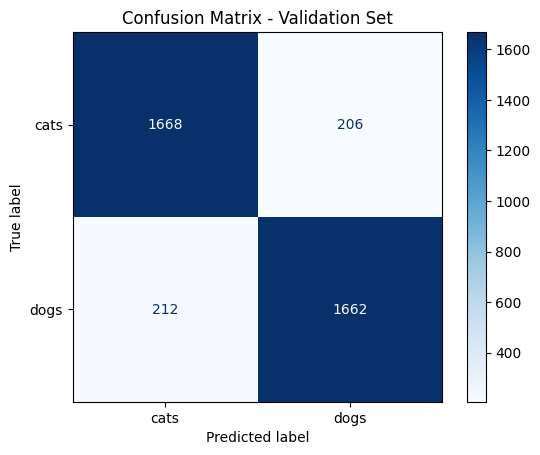

In [26]:
# Create empty lists to store the actual labels and the model predictions.
true_labels = []
predicted_labels = []

# Switch the model to evaluation mode.
# This disables training-specific behavior such as Dropout
# and makes Batch Normalization use the learned statistics.
model_BatchNormAndDropoutCNN_2.eval()

# Disable gradient calculations because we are only evaluating the model.
# This reduces memory usage and speeds up the evaluation process.
with torch.no_grad():

    # Iterate through all batches in the validation dataset.
    for images, labels in validation_loader:

        # Pass the validation images through the model
        # and obtain the output scores for each class.
        outputs = model_BatchNormAndDropoutCNN_2(images)

        # Select the class with the highest output score
        # as the predicted class for each image.
        predictions = outputs.argmax(dim=1)

        # Store the actual class labels.
        true_labels.extend(labels.cpu().numpy())

        # Store the predicted class labels.
        predicted_labels.extend(predictions.cpu().numpy())

# Create the confusion matrix by comparing
# the actual labels with the predicted labels.
cm = confusion_matrix(
    true_labels,
    predicted_labels,
)

# Prepare the confusion matrix for visualization
# and assign the class names to the axes.
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

# Display the confusion matrix as a colored grid.
display.plot(cmap="Blues")

plt.title("Confusion Matrix - Validation Set")
plt.show()

In [27]:
class_names = test_loader.dataset.classes

supported_extensions = {".jpg", ".jpeg", ".png"}

for image_path in sorted(RANDOM_IMAGES_DIR.iterdir()):

    if image_path.suffix.lower() not in supported_extensions:
        continue

    predicted_class, confidence, image_tensor = predict_image(
        model=model_BatchNormAndDropoutCNN_2,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )

In [28]:
correct_predictions = 0
total_images = 0

for image_path in sorted(RANDOM_IMAGES_DIR.iterdir()):

    if image_path.suffix.lower() not in supported_extensions:
        continue

    predicted_class, confidence, image_tensor = predict_image(
        model=model_BatchNormAndDropoutCNN_2,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )

    if image_path.stem.startswith("cat"):
        actual_class = "cats"
    elif image_path.stem.startswith("dog"):
        actual_class = "dogs"
    else:
        continue

    is_correct = predicted_class == actual_class

    correct_predictions += int(is_correct)
    total_images += 1

    print(
        f"{image_path.name} | "
        f"Actual: {actual_class} | "
        f"Predicted: {predicted_class} | "
        f"Confidence: {confidence:.2%} | "
        f"Correct: {is_correct}"
    )

external_accuracy = correct_predictions / total_images

print()
print(f"Correct predictions: {correct_predictions}/{total_images}")
print(f"External images accuracy: {external_accuracy:.2%}")

cat-1.jpg | Actual: cats | Predicted: cats | Confidence: 98.60% | Correct: True
cat-10.jpg | Actual: cats | Predicted: cats | Confidence: 75.45% | Correct: True
cat-11.jpg | Actual: cats | Predicted: cats | Confidence: 96.23% | Correct: True
cat-12.jpg | Actual: cats | Predicted: cats | Confidence: 89.95% | Correct: True
cat-13.jpg | Actual: cats | Predicted: dogs | Confidence: 72.27% | Correct: False
cat-14.jpg | Actual: cats | Predicted: cats | Confidence: 100.00% | Correct: True
cat-15.jpg | Actual: cats | Predicted: dogs | Confidence: 57.09% | Correct: False
cat-16.jpg | Actual: cats | Predicted: cats | Confidence: 99.98% | Correct: True
cat-17.jpg | Actual: cats | Predicted: cats | Confidence: 99.62% | Correct: True
cat-18.jpg | Actual: cats | Predicted: cats | Confidence: 96.67% | Correct: True
cat-19.jpg | Actual: cats | Predicted: cats | Confidence: 99.90% | Correct: True
cat-2.jpg | Actual: cats | Predicted: cats | Confidence: 85.86% | Correct: True
cat-20.jpg | Actual: cats |

## Error Analysis

In [29]:
image_path = "../02_notebooks/random_imgs/dog-4.jpg"
image_path

'../02_notebooks/random_imgs/dog-4.jpg'

In [30]:
# Predict the class of the selected image and return
# the prediction confidence together with the input tensor.
predicted_class, confidence, image_tensor = predict_image(
        model=model_BatchNormAndDropoutCNN_2,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )
predicted_class, confidence

('cats', 0.7029035091400146)

In [31]:
# Select the last convolutional layer for Grad-CAM visualization.
target_layers = [model_BatchNormAndDropoutCNN_2.features[10]]
target_layers

[Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))]

In [32]:
# Initialize Grad-CAM using the trained model and the selected convolutional layer.
cam = GradCAM(model=model_BatchNormAndDropoutCNN_2, target_layers=target_layers)
cam

In [33]:
# Generate the Grad-CAM heatmap for the selected input image.
grayscale_cam = cam(input_tensor=image_tensor)[0]
grayscale_cam

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(128, 128), dtype=float32)

In [34]:
# Load the original image, resize it to match the model input size,
# and convert it to a normalized NumPy array for Grad-CAM visualization.
image = Image.open(image_path).convert("RGB")
image = image.resize((128, 128))

rgb_image = np.array(image) / 255.0

In [35]:
# Overlay the Grad-CAM heatmap on the original image to visualize
# the regions that influenced the model's prediction.
visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True,
)

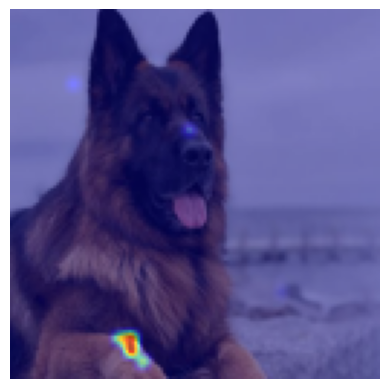

In [36]:
plt.imshow(visualization)
plt.axis("off")
plt.show()

The Grad-CAM visualization shows that the model focuses primarily on the cat's face and body, indicating that it uses meaningful visual features for prediction. However, attention is also given to the surrounding background and text, which may have contributed to the incorrect classification. This suggests that the model can still be influenced by irrelevant image regions in challenging examples.

In [37]:
def analysis_prediction(img_path):

    predicted_class, confidence, image_tensor = predict_image(
            model=model_BatchNormAndDropoutCNN_2,
            image_path=img_path,
            transform=prediction_transform,
            class_names=class_names,
        )

    target_layers = [model_BatchNormAndDropoutCNN_2.features[10]]

    cam = GradCAM(model=model_BatchNormAndDropoutCNN_2, target_layers=target_layers)

    grayscale_cam = cam(input_tensor=image_tensor)[0]

    image = Image.open(img_path).convert("RGB")
    image = image.resize((128, 128))

    rgb_image = np.array(image) / 255.0

    visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

    plt.imshow(visualization)
    plt.axis("off")
    plt.show()

In [38]:
img_path = "../02_notebooks/random_imgs/dog-4.jpg"

In [39]:
predicted_class, confidence, image_tensor = predict_image(
            model=model_BatchNormAndDropoutCNN_2,
            image_path=img_path,
            transform=prediction_transform,
            class_names=class_names,
        )
predicted_class

'cats'

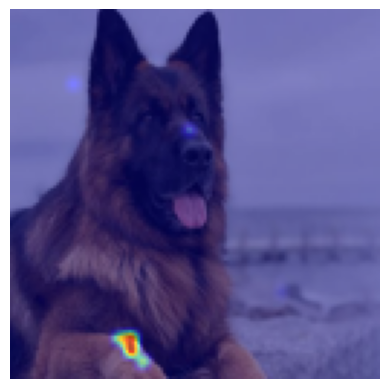

In [40]:
analysis_prediction(img_path)

### Experiment 4: BatchNorm + Dropout CNN with Global Average Pooling

In [41]:
# Define the project root based on the current notebook location.
PROJECT_ROOT = Path.cwd().parent

# Define the directory containing reusable project modules.
SRC_DIR = PROJECT_ROOT / "src"

# Add the src directory to Python module search path.
# This allows importing custom modules located inside the src directory.
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

# Define the path to the saved model weights.
Y_MODEL_PATH = (PROJECT_ROOT / "04_models" / "model_GlobalAveragePoolingCNN.pth")

print(Y_MODEL_PATH)

# Create the training, validation, and test data loaders.
# Each loader returns batches of preprocessed images and their labels.
train_loader, validation_loader, test_loader = create_data_loaders()

# Define the preprocessing pipeline used for individual image predictions.
# The preprocessing must match the transformations used during model training,
# except for training-specific augmentation such as random rotation or flipping.
prediction_transform = Compose([
    Resize((128, 128)),
    ToTensor(),
    Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])


def predict_image(model, image_path, transform, class_names):

    # Switch the model to evaluation mode.
    # This disables Dropout and makes BatchNorm use its learned statistics.
    model.eval()

    # Load the image from the path.
    image = Image.open(image_path)

    # Palette images may store transparency information separately.
    # Convert them to RGBA first to prevent transparency-related warnings.
    if image.mode == "P" and "transparency" in image.info:
        image = image.convert("RGBA")

    # Convert every image to RGB to guarantee exactly three input channels.
    image = image.convert("RGB")

    # Apply resizing, tensor conversion, and normalization.
    image_tensor = transform(image).unsqueeze(0)

    # Disable gradient calculation because gradients are not required
    # during inference. This reduces memory usage and improves performance.
    with torch.no_grad():

        # Pass the image through the model.
        # The output contains raw class scores called logits.
        outputs = model(image_tensor)

        # Convert logits into class probabilities using Softmax. -> изчисляват се експонентите на двата лоджита, след това се разделя експонентата на сбора от експонентите. По този начин softmax функцията, превръща Logits във вероятности.
        probabilities = torch.softmax(outputs, dim=1)

        # Find the index of the class with the highest probability.
        predicted_index = probabilities.argmax(dim=1).item()

        # Extract the probability assigned to the predicted class.
        confidence = probabilities[0, predicted_index].item()

    # Convert the predicted numerical index into a readable class name.
    predicted_class = class_names[predicted_index]

    return predicted_class, confidence, image_tensor


# Import an adaptive pooling layer from the timm library.
# The layer converts feature maps of different spatial sizes into
# a fixed-size representation.
from timm.layers import AdaptiveAvgMaxPool2d


class GlobalAveragePoolingCNN(Module):
    """
    The model extracts increasingly complex visual features through five
    convolutional blocks. Adaptive pooling then reduces the spatial dimensions
    before the final classification layer produces two logits.
    """

    def __init__(self):
        super().__init__()

        # Feature extraction section.
        #
        # Each convolutional block performs:
        # 1. Convolution for visual feature extraction.
        # 2. Batch normalization for more stable training.
        # 3. ReLU activation for non-linearity.
        # 4. Max pooling for spatial downsampling.
        # 5. Dropout2d for regularization.
        #
        # The number of channels gradually increases:
        # 3 - 32 - 64 - 128 - 256 - 512.
        self.features = Sequential(

            # Block 1:
            # Input shape:  [batch_size, 3, 128, 128]
            # Output shape after pooling: [batch_size, 32, 64, 64]
            Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            BatchNorm2d(num_features=32),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            # Block 2:
            # Output shape after pooling: [batch_size, 64, 32, 32]
            Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            BatchNorm2d(num_features=64),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            # Block 3:
            # Output shape after pooling: [batch_size, 128, 16, 16]
            Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            BatchNorm2d(num_features=128),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            # Block 4:
            # Output shape after pooling: [batch_size, 256, 8, 8]
            Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            BatchNorm2d(num_features=256),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            # Block 5:
            # Output shape after pooling: [batch_size, 512, 4, 4]
            Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            BatchNorm2d(num_features=512),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),
        )

        # Reduce every feature map to a fixed spatial size of 1 x 1.
        #
        # This removes the need for a large fully connected layer and allows
        # the architecture to work with different image dimensions.
        self.pooling = AdaptiveAvgMaxPool2d(output_size=(1, 1))

        # Classification section.
        #
        # Flatten converts the pooled feature representation into a vector.
        # Dropout reduces overfitting.
        # The final Linear layer produces two logits:
        # one for the cat class and one for the dog class.
        self.classifier = Sequential(
            Flatten(),
            Dropout(p=0.5),
            Linear(in_features=512, out_features=2),
        )

    def forward(self, x):
        # Extract hierarchical visual features.
        x = self.features(x)

        # Convert the spatial feature maps into a compact representation.
        x = self.pooling(x)

        # Produce the final class logits.
        x = self.classifier(x)

        return x


# Create a new instance of the model architecture.
# The architecture must be identical to the architecture used during training.
model_GlobalAveragePoolingCNN = GlobalAveragePoolingCNN()


# Load the previously trained model weights from disk.
# map_location="cpu" ensures that the model can be loaded on a machine
# without a GPU, even if it was originally trained using CUDA.
model_GlobalAveragePoolingCNN.load_state_dict(
    torch.load(
        Y_MODEL_PATH,
        map_location="cpu",
        weights_only=True,
    )
)


# Switch the model to evaluation mode before validation and prediction.
model_GlobalAveragePoolingCNN.eval()

print("Model loaded successfully.")


# Initialize counters used to calculate validation accuracy.
correct_predictions = 0
total_samples = 0

model_GlobalAveragePoolingCNN.eval()


# Disable gradient tracking because validation does not update model weights.
with torch.no_grad():

    # Process the validation dataset one batch at a time.
    for images, labels in validation_loader:

        # Generate two logits for every image in the current batch.
        outputs = model_GlobalAveragePoolingCNN(images)

        # Select the class index with the highest logit.
        # Softmax is not required here because Softmax does not change
        # which class has the highest score.
        predictions = outputs.argmax(dim=1)

        # Count how many predictions match the correct labels.
        correct_predictions += (
            predictions == labels
        ).sum().item()

        # Add the current batch size to the total number of samples.
        total_samples += labels.size(0)


# Calculate validation accuracy as:
# number of correct predictions / total number of validation samples.
validation_accuracy = correct_predictions / total_samples

print(f"Validation accuracy: {validation_accuracy:.4f}")
print(f"Validation accuracy: {validation_accuracy:.2%}")


# Retrieve the ordered class names from the test dataset.
# For ImageFolder, the classes are normally ordered alphabetically:
# ["cats", "dogs"].
class_names = test_loader.dataset.classes


# Define the image extensions accepted by the prediction loop.
supported_extensions = {".jpg", ".jpeg", ".png"}


# Iterate through the files in the random images directory
# in deterministic alphabetical order.
for image_path in sorted(RANDOM_IMAGES_DIR.iterdir()):

    # Ignore directories and unsupported file formats.
    if (
        not image_path.is_file()
        or image_path.suffix.lower() not in supported_extensions
    ):
        continue

    # Predict the class and confidence for the current image.
    predicted_class, confidence, image_tensor = predict_image(
        model=model_GlobalAveragePoolingCNN,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )

C:\Users\sveto\OneDrive\Desktop\cats_and_dogs_classification\04_models\model_GlobalAveragePoolingCNN.pth
Model loaded successfully.
Validation accuracy: 0.9448
Validation accuracy: 94.48%


In [42]:
correct_predictions = 0
total_images = 0

for image_path in sorted(RANDOM_IMAGES_DIR.iterdir()):

    if image_path.suffix.lower() not in supported_extensions:
        continue

    predicted_class, confidence, image_tensor = predict_image(
        model=model_GlobalAveragePoolingCNN,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )

    if image_path.stem.startswith("c"):
        actual_class = "cats"
    elif image_path.stem.startswith("d"):
        actual_class = "dogs"
    else:
        continue

    is_correct = predicted_class == actual_class

    correct_predictions += int(is_correct)
    total_images += 1

    print(
        f"{image_path.name} | "
        f"Actual: {actual_class} | "
        f"Predicted: {predicted_class} | "
        f"Confidence: {confidence:.2%} | "
        f"Correct: {is_correct}"
    )

external_accuracy = correct_predictions / total_images

print()
print(f"Correct predictions: {correct_predictions}/{total_images}")
print(f"External images accuracy: {external_accuracy:.2%}")

c1.jpg | Actual: cats | Predicted: cats | Confidence: 90.53% | Correct: True
c11.jpg | Actual: cats | Predicted: cats | Confidence: 94.70% | Correct: True
c111.jpg | Actual: cats | Predicted: cats | Confidence: 89.24% | Correct: True
c2.jpg | Actual: cats | Predicted: cats | Confidence: 99.19% | Correct: True
c22.jpg | Actual: cats | Predicted: cats | Confidence: 96.40% | Correct: True
c3.jpg | Actual: cats | Predicted: dogs | Confidence: 81.08% | Correct: False
c33.jpg | Actual: cats | Predicted: dogs | Confidence: 50.32% | Correct: False
c4.jpg | Actual: cats | Predicted: cats | Confidence: 99.11% | Correct: True
c44.jpg | Actual: cats | Predicted: cats | Confidence: 97.65% | Correct: True
c5.jpg | Actual: cats | Predicted: cats | Confidence: 75.56% | Correct: True
c55.jpg | Actual: cats | Predicted: cats | Confidence: 92.14% | Correct: True
cat-1.jpg | Actual: cats | Predicted: cats | Confidence: 90.53% | Correct: True
cat-10.jpg | Actual: cats | Predicted: cats | Confidence: 66.53%

### Experiment 4 - ## Error Analysis

In [43]:
image_path = "../02_notebooks/random_imgs/c3.jpg"

predicted_class, confidence, image_tensor = predict_image(
        model=model_GlobalAveragePoolingCNN,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )
predicted_class, confidence

('dogs', 0.8108134865760803)

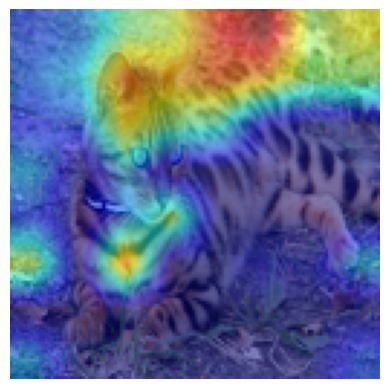

In [44]:
# Select the last convolutional layer for Grad-CAM visualization.
target_layers = [model_GlobalAveragePoolingCNN.features[20]]
target_layers

# Initialize Grad-CAM using the trained model and the selected convolutional layer.
cam = GradCAM(model=model_GlobalAveragePoolingCNN, target_layers=target_layers)
cam

# Generate the Grad-CAM heatmap for the selected input image.
grayscale_cam = cam(input_tensor=image_tensor)[0]
grayscale_cam

image = Image.open(image_path).convert("RGB")
image = image.resize((128, 128))

rgb_image = np.array(image) / 255.0

# Overlay the Grad-CAM heatmap on the original image to visualize
# the regions that influenced the model's prediction.
visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True,
)
plt.imshow(visualization)
plt.axis("off")
plt.show()

For the image dog-4.jpg, we observe that the second model (model_GlobalAveragePoolingCNN) uses a larger portion of the image to make its classification. During the first experiment, the model (model_BatchNormAndDropoutCNN_2) misclassified the image. In the second experiment (model_GlobalAveragePoolingCNN), however, it correctly classified it.

### Experiment 5 - 100 epochs
---

In [45]:
# Define the project root based on the current notebook location.
PROJECT_ROOT = Path.cwd().parent

# Define the directory containing reusable project modules.
SRC_DIR = PROJECT_ROOT / "src"

# Add the src directory to Python module search path.
# This allows importing custom modules located inside the src directory.
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

# Define the path to the saved model weights.
Y_MODEL_PATH = (PROJECT_ROOT / "04_models" / "model_GlobalAveragePoolingCNN_100.pth")

print(Y_MODEL_PATH)

# Create the training, validation, and test data loaders.
# Each loader returns batches of preprocessed images and their labels.
train_loader, validation_loader, test_loader = create_data_loaders()

# Define the preprocessing pipeline used for individual image predictions.
# The preprocessing must match the transformations used during model training,
# except for training-specific augmentation such as random rotation or flipping.
prediction_transform = Compose([
    Resize((128, 128)),
    ToTensor(),
    Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])


def predict_image(model, image_path, transform, class_names):

    # Switch the model to evaluation mode.
    # This disables Dropout and makes BatchNorm use its learned statistics.
    model.eval()

    # Load the image from the path.
    image = Image.open(image_path)

    # Palette images may store transparency information separately.
    # Convert them to RGBA first to prevent transparency-related warnings.
    if image.mode == "P" and "transparency" in image.info:
        image = image.convert("RGBA")

    # Convert every image to RGB to guarantee exactly three input channels.
    image = image.convert("RGB")

    # Apply resizing, tensor conversion, and normalization.
    image_tensor = transform(image).unsqueeze(0)

    # Disable gradient calculation because gradients are not required
    # during inference. This reduces memory usage and improves performance.
    with torch.no_grad():

        # Pass the image through the model.
        # The output contains raw class scores called logits.
        outputs = model(image_tensor)

        # Convert logits into class probabilities using Softmax. -> изчисляват се експонентите на двата лоджита, след това се разделя експонентата на сбора от експонентите. По този начин softmax функцията, превръща Logits във вероятности.
        probabilities = torch.softmax(outputs, dim=1)

        # Find the index of the class with the highest probability.
        predicted_index = probabilities.argmax(dim=1).item()

        # Extract the probability assigned to the predicted class.
        confidence = probabilities[0, predicted_index].item()

    # Convert the predicted numerical index into a readable class name.
    predicted_class = class_names[predicted_index]

    return predicted_class, confidence, image_tensor


# Import an adaptive pooling layer from the timm library.
# The layer converts feature maps of different spatial sizes into
# a fixed-size representation.
from timm.layers import AdaptiveAvgMaxPool2d


class GlobalAveragePoolingCNN(Module):
    """
    The model extracts increasingly complex visual features through five
    convolutional blocks. Adaptive pooling then reduces the spatial dimensions
    before the final classification layer produces two logits.
    """

    def __init__(self):
        super().__init__()

        # Feature extraction section.
        #
        # Each convolutional block performs:
        # 1. Convolution for visual feature extraction.
        # 2. Batch normalization for more stable training.
        # 3. ReLU activation for non-linearity.
        # 4. Max pooling for spatial downsampling.
        # 5. Dropout2d for regularization.
        #
        # The number of channels gradually increases:
        # 3 - 32 - 64 - 128 - 256 - 512.
        self.features = Sequential(

            # Block 1:
            # Input shape:  [batch_size, 3, 128, 128]
            # Output shape after pooling: [batch_size, 32, 64, 64]
            Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            BatchNorm2d(num_features=32),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            # Block 2:
            # Output shape after pooling: [batch_size, 64, 32, 32]
            Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            BatchNorm2d(num_features=64),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            # Block 3:
            # Output shape after pooling: [batch_size, 128, 16, 16]
            Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            BatchNorm2d(num_features=128),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            # Block 4:
            # Output shape after pooling: [batch_size, 256, 8, 8]
            Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            BatchNorm2d(num_features=256),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            # Block 5:
            # Output shape after pooling: [batch_size, 512, 4, 4]
            Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            BatchNorm2d(num_features=512),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),
        )

        # Reduce every feature map to a fixed spatial size of 1 x 1.
        #
        # This removes the need for a large fully connected layer and allows
        # the architecture to work with different image dimensions.
        self.pooling = AdaptiveAvgMaxPool2d(output_size=(1, 1))

        # Classification section.
        #
        # Flatten converts the pooled feature representation into a vector.
        # Dropout reduces overfitting.
        # The final Linear layer produces two logits:
        # one for the cat class and one for the dog class.
        self.classifier = Sequential(
            Flatten(),
            Dropout(p=0.5),
            Linear(in_features=512, out_features=2),
        )

    def forward(self, x):
        # Extract hierarchical visual features.
        x = self.features(x)

        # Convert the spatial feature maps into a compact representation.
        x = self.pooling(x)

        # Produce the final class logits.
        x = self.classifier(x)

        return x


# Create a new instance of the model architecture.
# The architecture must be identical to the architecture used during training.
model_GlobalAveragePoolingCNN_100 = GlobalAveragePoolingCNN()


# Load the previously trained model weights from disk.
# map_location="cpu" ensures that the model can be loaded on a machine
# without a GPU, even if it was originally trained using CUDA.
model_GlobalAveragePoolingCNN_100.load_state_dict(
    torch.load(
        Y_MODEL_PATH,
        map_location="cpu",
        weights_only=True,
    )
)


# Switch the model to evaluation mode before validation and prediction.
model_GlobalAveragePoolingCNN_100.eval()

print("Model loaded successfully.")


# Initialize counters used to calculate validation accuracy.
correct_predictions = 0
total_samples = 0

model_GlobalAveragePoolingCNN_100.eval()


# Disable gradient tracking because validation does not update model weights.
with torch.no_grad():

    # Process the validation dataset one batch at a time.
    for images, labels in validation_loader:

        # Generate two logits for every image in the current batch.
        outputs = model_GlobalAveragePoolingCNN_100(images)

        # Select the class index with the highest logit.
        # Softmax is not required here because Softmax does not change
        # which class has the highest score.
        predictions = outputs.argmax(dim=1)

        # Count how many predictions match the correct labels.
        correct_predictions += (
            predictions == labels
        ).sum().item()

        # Add the current batch size to the total number of samples.
        total_samples += labels.size(0)


# Calculate validation accuracy as:
# number of correct predictions / total number of validation samples.
validation_accuracy = correct_predictions / total_samples

print(f"Validation accuracy: {validation_accuracy:.4f}")
print(f"Validation accuracy: {validation_accuracy:.2%}")


# Retrieve the ordered class names from the test dataset.
# For ImageFolder, the classes are normally ordered alphabetically:
# ["cats", "dogs"].
class_names = test_loader.dataset.classes


# Define the image extensions accepted by the prediction loop.
supported_extensions = {".jpg", ".jpeg", ".png"}


# Iterate through the files in the random images directory
# in deterministic alphabetical order.
for image_path in sorted(RANDOM_IMAGES_DIR.iterdir()):

    # Ignore directories and unsupported file formats.
    if (
        not image_path.is_file()
        or image_path.suffix.lower() not in supported_extensions
    ):
        continue

    # Predict the class and confidence for the current image.
    predicted_class, confidence, image_tensor = predict_image(
        model=model_GlobalAveragePoolingCNN_100,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )

C:\Users\sveto\OneDrive\Desktop\cats_and_dogs_classification\04_models\model_GlobalAveragePoolingCNN_100.pth
Model loaded successfully.
Validation accuracy: 0.9554
Validation accuracy: 95.54%


In [46]:
image_files = [
    file for file in sorted(RANDOM_IMAGES_DIR.iterdir())
    if file.suffix.lower() in supported_extensions
]

print(f"Found {len(image_files)} image files.")

Found 86 image files.


In [47]:
correct_predictions = 0
total_images = 0

for image_path in sorted(RANDOM_IMAGES_DIR.iterdir()):

    if image_path.suffix.lower() not in supported_extensions:
        continue

    predicted_class, confidence, image_tensor = predict_image(
        model=model_GlobalAveragePoolingCNN_100,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )

    if image_path.stem.startswith("c"):
        actual_class = "cats"
    elif image_path.stem.startswith("d"):
        actual_class = "dogs"
    else:
        continue

    is_correct = predicted_class == actual_class

    correct_predictions += int(is_correct)
    total_images += 1

    print(
        f"{image_path.name} | "
        f"Actual: {actual_class} | "
        f"Predicted: {predicted_class} | "
        f"Confidence: {confidence:.2%} | "
        f"Correct: {is_correct}"
    )

external_accuracy = correct_predictions / total_images

print()
print(f"Correct predictions: {correct_predictions}/{total_images}")
print(f"External images accuracy: {external_accuracy:.2%}")

c1.jpg | Actual: cats | Predicted: cats | Confidence: 95.80% | Correct: True
c11.jpg | Actual: cats | Predicted: cats | Confidence: 95.25% | Correct: True
c111.jpg | Actual: cats | Predicted: cats | Confidence: 95.30% | Correct: True
c2.jpg | Actual: cats | Predicted: cats | Confidence: 99.50% | Correct: True
c22.jpg | Actual: cats | Predicted: cats | Confidence: 97.61% | Correct: True
c3.jpg | Actual: cats | Predicted: dogs | Confidence: 71.57% | Correct: False
c33.jpg | Actual: cats | Predicted: cats | Confidence: 58.58% | Correct: True
c4.jpg | Actual: cats | Predicted: cats | Confidence: 99.32% | Correct: True
c44.jpg | Actual: cats | Predicted: cats | Confidence: 94.27% | Correct: True
c5.jpg | Actual: cats | Predicted: cats | Confidence: 67.74% | Correct: True
c55.jpg | Actual: cats | Predicted: cats | Confidence: 94.22% | Correct: True
cat-1.jpg | Actual: cats | Predicted: cats | Confidence: 95.80% | Correct: True
cat-10.jpg | Actual: cats | Predicted: cats | Confidence: 77.08% 

### Experiment 5 - Error analysis

In [51]:
image_path = "../02_notebooks/random_imgs/c3.jpg"

predicted_class, confidence, image_tensor = predict_image(
        model=model_GlobalAveragePoolingCNN_100,
        image_path=image_path,
        transform=prediction_transform,
        class_names=class_names,
    )
predicted_class, confidence, image_tensor

('dogs',
 0.7156906127929688,
 tensor([[[[-0.2157, -0.1686,  0.1137,  ..., -0.0510,  0.0510,  0.0745],
           [-0.2471, -0.1294,  0.1216,  ..., -0.0902, -0.0039,  0.0353],
           [-0.1451, -0.1373,  0.0431,  ...,  0.0039,  0.0510,  0.1686],
           ...,
           [-0.1922, -0.3569, -0.4745,  ..., -0.0667, -0.1294, -0.0824],
           [-0.4980, -0.6314, -0.5137,  ..., -0.1922, -0.1529, -0.0824],
           [-0.7255, -0.5843, -0.4902,  ..., -0.0510, -0.1294, -0.0902]],
 
          [[-0.0745, -0.0980,  0.1137,  ...,  0.1216,  0.1294,  0.1294],
           [-0.0824, -0.0118,  0.2157,  ...,  0.0353,  0.1137,  0.1529],
           [ 0.0353, -0.0902,  0.1529,  ...,  0.0118,  0.0980,  0.2314],
           ...,
           [-0.1686, -0.2627, -0.3569,  ..., -0.0588, -0.1294, -0.0824],
           [-0.4980, -0.6314, -0.4824,  ..., -0.1843, -0.1451, -0.0745],
           [-0.6157, -0.4431, -0.3176,  ..., -0.0431, -0.1294, -0.0510]],
 
          [[-0.2471, -0.2471,  0.0039,  ..., -0.0902,  0

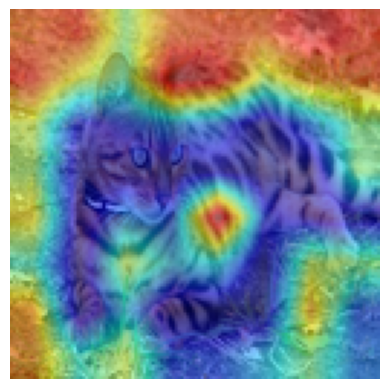

In [52]:
# Select the last convolutional layer for Grad-CAM visualization.
target_layers = [model_GlobalAveragePoolingCNN_100.features[20]]
target_layers

# Initialize Grad-CAM using the trained model and the selected convolutional layer.
cam = GradCAM(model=model_GlobalAveragePoolingCNN_100, target_layers=target_layers)
cam

# Generate the Grad-CAM heatmap for the selected input image.
grayscale_cam = cam(input_tensor=image_tensor)[0]
grayscale_cam

image = Image.open(image_path).convert("RGB")
image = image.resize((128, 128))

rgb_image = np.array(image) / 255.0

# Overlay the Grad-CAM heatmap on the original image to visualize
# the regions that influenced the model's prediction.
visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True,
)
plt.imshow(visualization)
plt.axis("off")
plt.show()

### Experiment 5 - errors
---

cat_y.jpg | Actual: cats | Predicted: dogs | Confidence: 71.61% | Correct: False

cat-4.jpg | Actual: cats | Predicted: dogs | Confidence: 57.56% | Correct: False

cat-29.jpg | Actual: cats | Predicted: dogs | Confidence: 77.63% | Correct: False

c3.jpg | Actual: cats | Predicted: dogs | Confidence: 71.57% | Correct: False

### Experiment 4 - errors
---

cat_y.jpg | Actual: cats | Predicted: dogs | Confidence: 71.08% | Correct: False

cat-4.jpg | Actual: cats | Predicted: dogs | Confidence: 51.43% | Correct: False

cat-29.jpg | Actual: cats | Predicted: dogs | Confidence: 69.21% | Correct: False

c3.jpg | Actual: cats | Predicted: dogs | Confidence: 81.08% | Correct: False

cat-5.jpg | Actual: cats | Predicted: dogs | Confidence: 52.66% | Correct: False

c33.jpg | Actual: cats | Predicted: dogs | Confidence: 50.32% | Correct: False

Experiment 5 and Experiment 4 use the same CNN architecture. The difference between the two models is that Experiment 4 was trained for 50 epochs, while Experiment 5 was trained for 100 epochs. I expected that increasing the number of training epochs would improve the model's accuracy. In practice, this expectation was confirmed, although the improvement was relatively small - aprox. 2%.

After evaluating the models on external images downloaded from the Internet that were not part of the training dataset, I observed that both models made very similar classification errors.

The model trained for 50 epochs made exactly the same classification mistakes as the model trained for 100 epochs, with two additional incorrect predictions.

This allows us to analyze the common misclassified images and investigate whether any conclusions can be drawn about where, why, and how our model fails during the classification process.


1. **cat_y.jpg** – Both models focus on the same region of the image, suggesting that they rely on the same visual features when making their prediction.

2. **cat-4.jpg** – Both models focus on the same region of the image, indicating that the learned feature representations are very similar despite the additional training epochs.

3. **cat-29.jpg** – Both models focus on the same region of the image. A notable characteristic of this image is that it contains two cats, and the models primarily focus on both cats' heads. The presence of two objects in the image may have contributed to the incorrect classification, as the object of interest occupies a relatively small portion of the overall image.

4. **c3.jpg** – Both models focus on the same region of the image, suggesting that the additional training epochs did not significantly change the model's attention for this sample.
